# Data audit: can we trust this dataset for fault detection?

This notebook checks the release before any modelling: do the files match the
published index, what do the units and raw-voltage channels mean, how often
did the bench log (and where did it skip), which channels are missing and
where, where each fault switches on, and which load bin each run falls in.
The findings drive the leakage and windowing rules used in every notebook
that follows.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from keyframe import audit, download, load, paths

paths.FIGURES.mkdir(parents=True, exist_ok=True)
paths.RESULTS.mkdir(parents=True, exist_ok=True)

## Do the files and row counts match the published index?

In [2]:
dataset_index = pd.read_csv(paths.RAW / "dataset_index.csv")
full_table = load.load_all(paths.RAW)

row_counts = dataset_index[~dataset_index["file_name"].str.endswith(download.LOCKBOX_FILE)].copy()
row_counts["run"] = row_counts["file_name"].str.split("/").str[-1].str.removesuffix(".csv")
row_counts["actual_rows"] = row_counts["run"].map(full_table.groupby("run").size())
row_counts["rows_match"] = row_counts["actual_rows"] == row_counts["data_rows"]
row_counts = row_counts[["run", "data_rows", "actual_rows", "rows_match", "columns"]]
row_counts.to_csv(paths.RESULTS / "00_row_counts.csv", index=False)
row_counts

,run,data_rows,actual_rows,rows_match,columns
0,Reference_Data,25302,25302,True,70
1,AC_Fouling_40_Load,4678,4678,True,73
2,AC_Fouling_60_Load,6698,6698,True,73
3,AC_Fouling_75_Load,6354,6354,True,73
4,AC_Fouling_85_Load,5801,5801,True,73
5,AF_Clogging_40_Load,4820,4820,True,73
6,AF_Clogging_60_Load,6819,6819,True,73
7,AF_Clogging_75_Load,5918,5918,True,73
8,AF_Clogging_85_Load,6398,6398,True,73
9,Clogged_Injector_Nozzle1_40_60_85_Load,6492,6492,True,73


## What units do the channels use, and which are raw voltages?

In [3]:
_, reference_columns = load.read_csv_with_header(paths.RAW / "Reference_Data.csv")
_, scenario_columns = load.read_csv_with_header(paths.RAW / "AC_Fouling" / "AC_Fouling_40_Load.csv")

raw_voltage_channels = scenario_columns.frame[scenario_columns.frame["is_raw_voltage"]]
raw_voltage_channels[["full_name", "symbol", "unit"]]

,full_name,symbol,unit
37,LO Circulating Pump Press.,Pl_lo,V
38,Fuel transfer pump Press.,Pl_fuel,V
39,Fresh Cooling Water Press.,Pl_water1,V
40,Sea Cooling Water Press.,Pl_water2,V
41,TCH LO pump Press.,Pl_loturb,V
42,Fuel Injector Cooling Oil Press.,Pl_valve,V


## How often did the bench log, and where does it skip?

The tech stack notes say sampling is not a fixed 2 s: time stamps step
alternately 1 s and 2 s (about 1.6 s on average). This section checks that
pattern and flags any gap over 4 s.

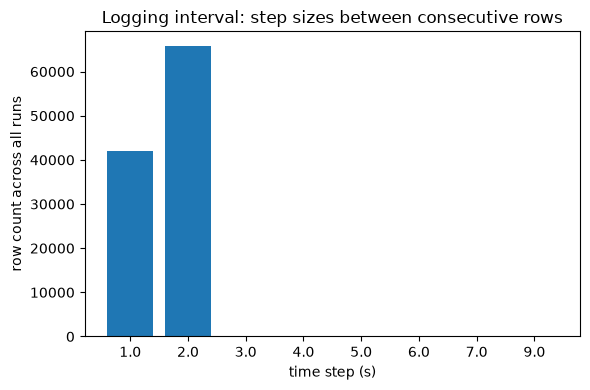

,run,max_gap_s,gaps_s
0,AC_Fouling_40_Load,3.0,[]
1,AC_Fouling_60_Load,2.0,[]
2,AC_Fouling_75_Load,3.0,[]
3,AC_Fouling_85_Load,3.0,[]
4,AF_Clogging_40_Load,5.0,[5.0]
5,AF_Clogging_60_Load,3.0,[]
6,AF_Clogging_75_Load,6.0,"[5.0, 6.0]"
7,AF_Clogging_85_Load,3.0,[]
8,Clogged_Injector_Nozzle1_40_60_85_Load,9.0,"[6.0, 7.0, 9.0]"
9,CW_Pump_Cavitation_60_Load,4.0,[]


In [4]:
intervals = audit.sampling_intervals(full_table)
step_values = sorted({round(v, 3) for counts in intervals["step_counts"] for v in counts})
step_totals = {v: sum(counts.get(v, 0) for counts in intervals["step_counts"]) for v in step_values}

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(v) for v in step_totals], step_totals.values())
ax.set_xlabel("time step (s)")
ax.set_ylabel("row count across all runs")
ax.set_title("Logging interval: step sizes between consecutive rows")
fig.tight_layout()
fig.savefig(paths.FIGURES / "00_sampling_intervals.png", dpi=150)
plt.show()

intervals[["run", "max_gap_s", "gaps_s"]]

## Which channels are missing, and where?

In [5]:
missing_channels = audit.missing_by_channel(full_table)
missing_channels.to_csv(paths.RESULTS / "00_missing_channels.csv", index=False)
missing_channels

,run,channel,missing_share
0,AC_Fouling_40_Load,Time,1.0
1,AC_Fouling_60_Load,Time,1.0
2,AC_Fouling_75_Load,Time,1.0
3,AC_Fouling_85_Load,Compressor Filter Loss,1.0
4,AC_Fouling_85_Load,Turbine Back Pressure,1.0
5,AC_Fouling_85_Load,Time,1.0
6,AF_Clogging_40_Load,Time,1.0
7,AF_Clogging_60_Load,Time,1.0
8,AF_Clogging_75_Load,Time,1.0
9,AF_Clogging_85_Load,Time,1.0
